# Логистическая регрессия и классификация
Логистическая регрессия прогнозирует вероятность того или иного исхода по одной или нескольким независимым переменным.

Результаты логистической регрессии можно использовать для классификации , то есть для того, чтобы предсказывать категории, а не числовые значения, как в случае с линейной регрессией.

###  Почему просто линейная регрессия не подходит для классификации?
Допустим, мы решаем задачу бинарной классификации: $y=0,y=1$.
Возбмём линейную регрессию $y=(w^T)x+b$.
Проблемы:
1. Выход за пределы [0,1]
2. Чувствительность к выбросам
3. Неправильная интерпретация — линейная регрессия минимизирует MSE, а не ошибку классификации.

Значит, нужно преобразовать выход линейной модели так, чтобы он лежал в интервале (0,1). Перейдём от предсказания y к предсказанию вереятности:
Пусть $z = (w^T)x+b$ выход линейной модели. Надо получить $p \in (0,1)$, которое можно интерпретировать как $P(y=1 \mid x)$
Нужна функция $\sigma(z)$, обладающая свойствами:
1. $\sigma(z) \in (0,1)$
2. Монотонно возрастает
3. $\sigma(0) = 0.5$
4. Имеет простую производную

Сигмоида: $\sigma(z) = \frac{1}{1 + e^{-z}}$

Её производная: $\sigma'(z) = \sigma(z)(1 - \sigma(z))$

Она идеально подходит, потому что:
- Является обратной функцией к логиту 
- Производная 
- очень удобна для градиентного спуска

### Связь с линейной регрессией через логит-преобразование

Линейная регрессия предсказывает условное математическое ожидание $\mathbb{E}[y \mid x].$
Для бинарной переменной $y \in \{0,1\}$:
$\mathbb{E}[y \mid x] = P(y = 1 \mid x)$.

Но почему не взять $P(y = 1 \mid x) = w^T x + b$?
Потому что вероятность должна быть от $0$ до $1$.

Логистическая регрессия:

$$
\ln\left( \frac{P(y = 1 \mid x)}{1 - P(y = 1 \mid x)} \right) = w^T x + b.
$$

Тогда, выражая $P(y = 1 \mid x)$:

$$
P = \frac{e^{w^T x + b}}{1 + e^{w^T x + b}} = \sigma(w^T x + b).
$$



In [2]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=50, n_features=2, random_state=12, centers=2)

display(X, y)

array([[ -5.2000508 ,   1.03101087],
       [ -6.26268518,   1.70399904],
       [ -6.09933951,  -0.51965652],
       [ -2.90487898,  -0.32621368],
       [ -7.51456607,   5.27345092],
       [ -7.91394699,   4.08713764],
       [ -4.93302704,   0.93256045],
       [ -6.27598204,   5.3283266 ],
       [ -3.73275694,   0.62337287],
       [ -6.88132681,   4.12304857],
       [ -5.30551643,   0.07148875],
       [ -8.59849966,   3.01289968],
       [ -7.2543384 ,   4.21572565],
       [ -3.2624657 ,   2.31125078],
       [ -3.79012431,   1.03243209],
       [ -6.41487085,   4.93984011],
       [ -6.16360032,   3.26627259],
       [ -7.94627336,   6.01079038],
       [ -3.86173157,  -0.77157158],
       [ -7.44514747,   4.76178476],
       [ -6.7017672 ,   4.41663513],
       [ -5.58091181,   5.11965922],
       [ -6.82539091,   0.82134757],
       [ -6.91161607,   4.68076626],
       [ -7.03166309,   7.04281172],
       [ -4.83896768,   1.18681003],
       [ -5.42257839,   1.47741832],
 

array([1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 1])

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)
X.mean(axis=0), X.std(axis=0)

(array([-7.77156117e-17, -2.22044605e-16]), array([1., 1.]))

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)
X.mean(axis=0), X.std(axis=0)

(array([-3.55271368e-17,  2.22044605e-17]), array([1., 1.]))

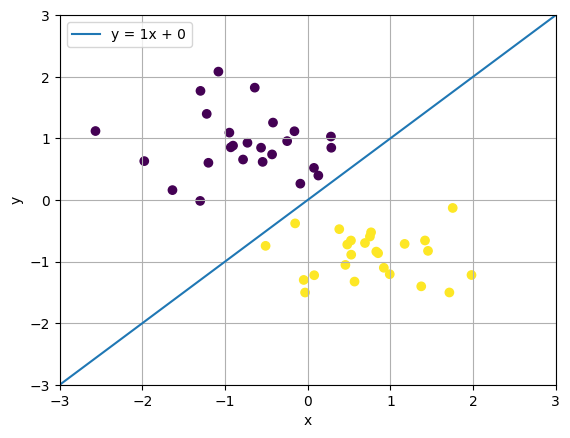

In [5]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(-3, 4)
a = 1
b = 0

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.plot(x, a * x + b, label=f'y = {a}x + {b}')
plt.ylabel('y');plt.xlabel('x')
plt.ylim(-3, 3);plt.xlim(-3, 3)
plt.grid()
plt.legend();

In [6]:
# Что в случае одномерной классификации?
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=25, n_features=1, n_informative=1,
                           n_redundant=0, random_state=11, n_clusters_per_class=1,
                           class_sep=0.4)

display(X, y)

array([[-0.86305361],
       [-1.4372011 ],
       [ 0.19592225],
       [-0.87164985],
       [ 0.00982831],
       [ 1.30282593],
       [ 0.16134434],
       [-0.9223264 ],
       [-0.10173176],
       [ 0.41006497],
       [ 0.27129997],
       [-0.71111212],
       [-2.98259876],
       [-0.09300387],
       [ 0.82285659],
       [ 0.16493473],
       [-0.40806382],
       [ 0.62136283],
       [ 0.76258897],
       [-0.11001122],
       [-1.26261842],
       [ 0.04513441],
       [ 0.50026937],
       [-0.6784482 ],
       [ 0.2182344 ]])

array([0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 1])

In [7]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
X.mean(axis=0), X.std(axis=0)

(array([1.77635684e-17]), array([1.]))

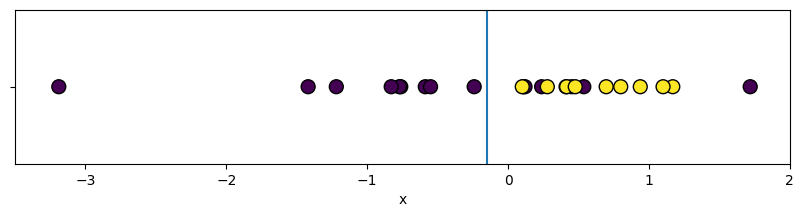

In [8]:
plt.figure(figsize=(10, 2))
plt.scatter(X, np.zeros(X.shape[0]), c=y, s=100, edgecolors='black')
plt.plot([-0.15, -0.15], [-1, 1])
plt.ylabel('');plt.xlabel('x')
plt.yticks(np.arange(0, 1), [''])
plt.ylim(-1, 1);plt.xlim(-3.5, 2);

$y = a* x + b$

a - ? b - ?

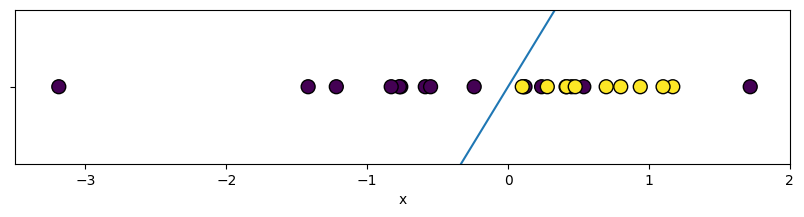

In [9]:
plt.figure(figsize=(10, 2))
plt.scatter(X, np.zeros(X.shape[0]), c=y, s=100, edgecolors='black')

x = np.linspace(-3, 3)
plt.plot(x, 3*x + 0)
plt.ylabel('');plt.xlabel('x')
plt.yticks(np.arange(0, 1), [''])
plt.ylim(-1, 1);plt.xlim(-3.5, 2);

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, y)
model.coef_, model.intercept_
model_a = model.coef_[0]
model_b = model.intercept_

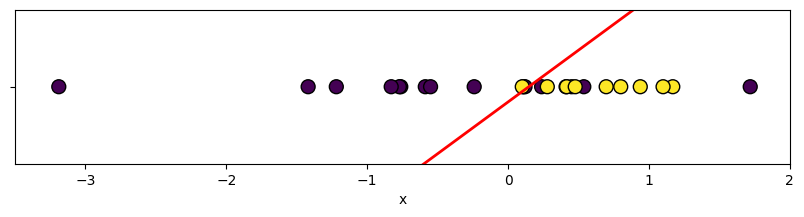

In [11]:
model_y_sk = model_a * x + model_b

plt.figure(figsize=(10, 2))
plt.plot(x, model_y_sk, linewidth=2, c='r')
plt.scatter(X, np.zeros(X.shape[0]), c=y, s=100, edgecolors='black')
plt.ylabel('');plt.xlabel('x')
plt.yticks(np.arange(0, 1), [''])
plt.ylim(-1, 1);plt.xlim(-3.5, 2);

In [12]:
model.score(X, y)
y_pred_cl = model.predict(X)
y_pred_cl[:5]

array([0, 0, 1, 0, 1])

Или же можем можем сделать точно такое же предсказание, если возьмем коэффициент наклона и умножим на значение признака и прибавим к этому коэффициент сдвига.

In [13]:
y_pred = model_a * X + model_b
y_pred[:5]

array([[-1.22187946],
       [-2.1060686 ],
       [ 0.40894703],
       [-1.23511771],
       [ 0.12236172]])

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


### **Вывод уравнения логистической регрессии и градиента её функции потерь**

$$
L(\sigma(z), y_i) = 
\begin{cases}
  -\ln\sigma(z) & \text{если } y_i = 1 \\
  -\ln(1 - \sigma(z)) & \text{если } y_i = 0
\end{cases}
$$
— начальная форма логистической функции потерь

$$
L(\sigma(z), y_i) = \prod_{i=1}^{n} \sigma(z)^{y_i} (1 - \sigma(z))^{1-y_i}
$$
— функция правдоподобия (метод максимального правдоподобия)

$$
L_{\text{log}}(\sigma(z), y_i) = -\big[y_i\ln\sigma(z) + (1 - y_i)\ln(1 - \sigma(z))\big]
$$
— логистическая функция потерь (логарифм правдоподобия)

$$
J(w, b) = \frac{1}{n} \sum_{i = 1}^{n} L_{\text{log}}(\sigma(z), y_i)
$$
— функция для всей обучающей выборки

**Градиенты функции по смещению и весам**

$$
\frac{\partial J(w, b)}{\partial b} = \frac{1}{n} \sum_{i = 1}^{n} \frac{\partial L_{\text{log}}(\sigma(z), y_i)}{\partial b} = \frac{1}{n} \sum_{i = 1}^{n} (\sigma(z) - y_i)
$$

$$
\frac{\partial J(w, b)}{\partial \omega} = \frac{1}{n} \sum_{i = 1}^{n} \frac{\partial L_{\text{log}}(\sigma(z), y_i)}{\partial \omega} = \frac{1}{n} \sum_{i = 1}^{n} (\sigma(z) - y_i)x_i
$$

**Частные производные логистической функции потерь по смещению и весам**

$$
\frac{\partial L_{\text{log}}(\sigma(z), y_i)}{\partial b} = \frac{\partial L_{\text{log}}}{\partial \sigma(z)} \cdot \frac{\partial \sigma(z)}{\partial z} \cdot \frac{\partial z}{\partial b}
$$

$$
\frac{\partial L_{\text{log}}(\sigma(z), y_i)}{\partial \omega} = \frac{\partial L_{\text{log}}}{\partial \sigma(z)} \cdot \frac{\partial \sigma(z)}{\partial z} \cdot \frac{\partial z}{\partial \omega}
$$

$$
\begin{aligned}
\frac{\partial L_{\text{log}}}{\partial \sigma(z)} &= -\left[y_i(\ln\sigma(z))' + (1 - y_i)(\ln(1 - \sigma(z)))'\right] \\
&= -\left[y_i \cdot \frac{1}{\sigma(z)} + (1 - y_i) \cdot \frac{-1}{1-\sigma(z)}\right] \\
&= \frac{1 - y_i}{1 - \sigma(z)} - \frac{y_i}{\sigma(z)} \\
&= \frac{\sigma(z) - \sigma(z)y_i - y_i + \sigma(z)y_i}{\sigma(z)(1 - \sigma(z))} \\
&= \frac{\sigma(z) - y_i}{\sigma(z)(1 - \sigma(z))}
\end{aligned}
$$

$$
\begin{aligned}
\frac{\partial \sigma(z)}{\partial z} &= \left((1 + e^{-z})^{-1}\right)' = \frac{e^{-z}}{(1 + e^{-z})^2} \\
&= \sigma(z) \cdot \frac{e^{-z}}{1 + e^{-z}} = \sigma(z)(1 - \sigma(z))
\end{aligned}
$$

$$
\frac{\partial z}{\partial b} = \frac{\partial}{\partial b}(w \cdot x_i + b) = 1
$$

$$
\frac{\partial z}{\partial \omega} = \frac{\partial}{\partial \omega}(w \cdot x_i + b) = x_i
$$

$$
\frac{\partial L_{\text{log}}}{\partial b} = \frac{\sigma(z) - y_i}{\sigma(z)(1 - \sigma(z))} \cdot \sigma(z)(1 - \sigma(z)) \cdot 1 = \sigma(z) - y_i
$$

$$
\frac{\partial L_{\text{log}}}{\partial \omega} = \frac{\sigma(z) - y_i}{\sigma(z)(1 - \sigma(z))} \cdot \sigma(z)(1 - \sigma(z)) \cdot x_i = (\sigma(z) - y_i)x_i
$$

**Где**:

- $\sigma(z) = \frac{1}{1 + e^{-z}}$ — сигмоидальная функция;
- $z_{w, b}(x_i) = w \cdot x_i + b$ — линейная функция;
- $b$ — смещение;
- $\omega$ — вектор весов;
- $x_i$ — вектор признаков $i$-го объекта.

# Преимущества и недостатки логистической регрессии
### Преимущества:

- простота в реализации и интерпретации;
- высокая скорость работы;
- относительно хорошая точность в случае с линейной зависимостью в данных.
### Недостатки:

- низкая гибкость и адаптивность из-за предположения о линейности данных;
- низкая точность в случае с данными сложной формы;
- чувствительность к шуму и выбросам.